In [ ]:
!pip install pymupdf4llm
!pip install chromadb
!pip install litellm
!pip install -U langchain langchain-community langchain-core langchain-text-splitters langgraph
!pip install -q -U transformers peft bitsandbytes accelerate datasets

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.0 MB/s eta 0:00:00


In [1]:
"""
entity_extractor.py — the single source of truth for entity extraction,
meant to be imported by both the Phase C evaluation script and the Phase 5
RAG ingestion pipeline (replacing EQUIPMENT_HAZARDS / REGULATORY_HAZARDS
hardcoded-dict lookups).

"""

import os
import re
import json

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
BASE_PATH = "/content/drive/MyDrive/ET_Industrial_data"
BASE_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"  # must match what Phase B actually trained
ADAPTER_DIR = os.path.join(BASE_PATH, "entity_model", "lora_adapter")

INSTRUCTION = (
    "Extract structured entities from this industrial document text. "
    "Return valid JSON only."
)
MAX_NEW_TOKENS = 256

KNOWN_FIELDS = {
    "equipment_id", "date", "record_type", "record_id", "person_role", "location",
    "section_number", "hazard_mentions", "dates", "source_document",
}
LIST_FIELDS = {"hazard_mentions", "dates"}

ALIAS_MAP = {
    "person_name": "person_role", "name": "person_role",
    "technician_role": "person_role", "role": "person_role", "technician": "person_role",
    "equipment": "equipment_id", "equipment_tag": "equipment_id", "tag": "equipment_id",
    "reg_reference": "section_number", "regulation_reference": "section_number",
    "section": "section_number",
}
ROLE_KEYWORDS = [
    "fitter", "officer", "engineer", "supervisor", "operator", "technician",
    "inspector", "manager", "in-charge", "incharge", "electrician", "welder",
    "foreman", "contractor", "safety officer",
]

# ---------------------------------------------------------
# MODEL LOADING (once, on import)
# ---------------------------------------------------------
_tokenizer = None
_model = None


def _load_model():
    global _tokenizer, _model
    if _model is not None:
        return
    _tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
    if _tokenizer.pad_token is None:
        _tokenizer.pad_token = _tokenizer.eos_token

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID, quantization_config=bnb_config, device_map="auto"
    )
    _model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
    _model.eval()
    print(f"[entity_extractor] loaded {BASE_MODEL_ID} + LoRA adapter from {ADAPTER_DIR}")


# ---------------------------------------------------------
# GENERATION
# ---------------------------------------------------------
def _build_prompt(input_text):
    messages = [
        {"role": "system", "content": INSTRUCTION},
        {"role": "user", "content": input_text},
    ]
    return _tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def generate_entities(input_text: str):
    """Returns (parsed_dict_or_None, raw_generated_string)."""
    _load_model()
    prompt = _build_prompt(input_text)
    inputs = _tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(_model.device)

    with torch.no_grad():
        output_ids = _model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=_tokenizer.pad_token_id,
        )

    raw = _tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    cleaned = re.sub(r'^```(?:json)?|```$', '', raw, flags=re.MULTILINE).strip()

    try:
        parsed = json.loads(cleaned)
        return (parsed, raw) if isinstance(parsed, dict) else (None, raw)
    except json.JSONDecodeError:
        return None, raw


# ---------------------------------------------------------
# NORMALIZATION (post-processing, no retraining)
# ---------------------------------------------------------
def _looks_like_role(value):
    if not isinstance(value, str):
        return False
    v = value.lower()
    return any(kw in v for kw in ROLE_KEYWORDS)


def normalize_entities(raw: dict) -> dict:
    """
    - Maps aliased/unexpected keys back onto the known training schema
    - Fixes the name<->role swap pattern seen when the model meets
      formatting it wasn't trained on (e.g. inline "Name (Role)")
    - Coerces missing list fields (hazard_mentions, dates) to []
    - Preserves genuinely unrecognized fields under "_unmapped" instead of
      silently dropping them, so future format drift stays visible
    """
    if not isinstance(raw, dict):
        return {"hazard_mentions": [], "dates": [], "_unmapped": {}}

    out, unmapped = {}, {}

    for key, value in raw.items():
        if key in KNOWN_FIELDS:
            if key not in out or not out[key]:
                out[key] = value
            continue
        target = ALIAS_MAP.get(key)
        if target:
            if target not in out or not out[target]:
                out[target] = value
            else:
                unmapped[key] = value
        else:
            unmapped[key] = value

    if "person_role" in out and not _looks_like_role(out["person_role"]):
        swap_key = next((k for k, v in unmapped.items() if _looks_like_role(v)), None)
        if swap_key:
            name_value = out["person_role"]
            out["person_role"] = unmapped.pop(swap_key)
            out["person_full_name"] = name_value

    for lf in LIST_FIELDS:
        if lf not in out or out[lf] is None:
            out[lf] = []
        elif not isinstance(out[lf], list):
            out[lf] = [out[lf]]

    if unmapped:
        out["_unmapped"] = unmapped

    return out


# ---------------------------------------------------------
# PUBLIC ENTRY POINT — call this from the RAG ingestion pipeline
# ---------------------------------------------------------
def extract_entities(chunk: dict) -> dict:
    """
    Replaces the hardcoded EQUIPMENT_HAZARDS / REGULATORY_HAZARDS dict
    lookups in the Phase 5 ingestion pipeline.

    chunk: {"text": str, "metadata": {"source": ..., "chunk_id": ..., ...}}
    Returns a normalized entities dict. source_document and chunk_id are
    always taken from metadata, never predicted by the model.
    """
    text = chunk.get("text", "")
    metadata = chunk.get("metadata", {})

    parsed, raw = generate_entities(text)
    if parsed is None:
        entities = {"_extraction_failed": True, "_raw_output": raw, "hazard_mentions": [], "dates": []}
    else:
        entities = normalize_entities(parsed)

    entities["source_document"] = metadata.get("source", "UNKNOWN")
    entities["chunk_id"] = metadata.get("chunk_id", "UNKNOWN")
    return entities


if __name__ == "__main__":
    # quick smoke test with the same "unseen" demo document from Phase C
    demo_chunk = {
        "text": (
            "Maintenance Log — Unit REACTOR-R7\n"
            "Date: 14/03/2026\n"
            "Technician: J. Fernandes (Senior Mechanical Fitter)\n"
            "Observation: Recurrent vibration detected on the agitator shaft "
            "bearing housing during routine inspection. Isolated per LOTO "
            "procedure before opening the housing. No gas leakage or pressure "
            "anomaly observed during the isolation window. Bearing replaced; "
            "unit returned to service after function test."
        ),
        "metadata": {
            "source": "unit_r7_maintenance_log_2026_03.pdf",
            "chunk_id": "demo_new_doc_001",
            "doc_type": "maintenance",
        },
    }
    print(json.dumps(extract_entities(demo_chunk), indent=2))

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[entity_extractor] loaded Qwen/Qwen2.5-1.5B-Instruct + LoRA adapter from /content/drive/MyDrive/ET_Industrial_data/entity_model/lora_adapter


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{
  "equipment_id": "REACTOR-R7",
  "date": "14/03/2026",
  "person_role": "Mechanical Fitter",
  "person_full_name": "J. Fernandes",
  "hazard_mentions": [],
  "dates": [],
  "source_document": "unit_r7_maintenance_log_2026_03.pdf",
  "chunk_id": "demo_new_doc_001"
}


In [2]:
#phase5
import os
import json
import hashlib
import re
import pickle
import time
from typing import TypedDict, List, Dict, Any, Annotated

import collections
import pymupdf4llm
import chromadb
import networkx as nx
from chromadb.utils import embedding_functions
from litellm import completion
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from google.colab import userdata, drive

_call_timestamps = collections.deque()
RATE_LIMIT_CALLS = 4      # stay under the real 5/min cap with margin
RATE_LIMIT_WINDOW = 62    # seconds, slightly over 60 for safety

def throttled_completion(**kwargs):
    now = time.time()
    while _call_timestamps and now - _call_timestamps[0] > RATE_LIMIT_WINDOW:
        _call_timestamps.popleft()

    if len(_call_timestamps) >= RATE_LIMIT_CALLS:
        wait = RATE_LIMIT_WINDOW - (now - _call_timestamps[0]) + 1
        print(f"⏳ Rate limit guard: API cap reached, waiting {wait:.0f}s...")
        time.sleep(wait)
        now = time.time()
        while _call_timestamps and now - _call_timestamps[0] > RATE_LIMIT_WINDOW:
            _call_timestamps.popleft()

    _call_timestamps.append(now)
    return completion(**kwargs)

# ---------------------------------------------------------
# 0. CONFIG & ONTOLOGY
# ---------------------------------------------------------
MODEL_NAME = "gemini/gemini-3.5-flash"
EMBED_MODEL = "all-MiniLM-L6-v2"

EQUIPMENT_HAZARDS = {
    "PUMP-14": ["Flammable Gas", "High Pressure", "Mechanical"],
    "COKE-OVEN-02": ["Thermal/Heat", "Toxic/Asphyxiant Gas", "Confined Space"],
    "BOILER-B1": ["High Pressure", "Thermal/Heat"],
    "VALVE-102": ["High Pressure", "Chemical Leak"],
    "CONVEYOR-C3": ["Mechanical", "Fire/Dust"],
    "COMPRESSOR-A": ["High Pressure", "Mechanical"],
    "STORAGE-TANK-T5": ["Confined Space", "Flammable Gas"],
    "TRANSFORMER-TR1": ["Electrical", "Thermal/Heat"],
    "EXHAUST-FAN-F2": ["Mechanical"],
    "CRANE-OH-01": ["Mechanical"],
}
REGULATORY_HAZARDS = {
    "factories_act_1948.pdf": ["Mechanical", "Thermal/Heat", "High Pressure", "Confined Space", "Chemical Leak"],
    "dgms_2020_04_gas_hazards.pdf": ["Flammable Gas", "Toxic/Asphyxiant Gas"],
    "dgms_2017_loto_procedures.pdf": ["Electrical", "Mechanical", "High Pressure"],
    "dgms_2020_05_oil_gas_safety.pdf": ["High Pressure", "Flammable Gas"],
}
KNOWN_HAZARDS = list(set(h for lst in EQUIPMENT_HAZARDS.values() for h in lst))
# ---------------------------------------------------------
# ENTITY EXTRACTOR INTEGRATION (uses extract_entities from cell 3)
# ---------------------------------------------------------
entity_cache_path = os.path.join(BASE_PATH, "entity_training", "entity_extraction_cache.json")

def load_entity_cache(path):
    return json.load(open(path, encoding="utf-8")) if os.path.exists(path) else {}

def save_entity_cache(path, cache):
    json.dump(cache, open(path, "w", encoding="utf-8"), ensure_ascii=False, indent=2)

def sanitize_for_chroma(entities: dict) -> dict:
    clean = {}
    for k, v in entities.items():
        if v is None:
            continue
        if isinstance(v, list):
            clean[k] = ", ".join(str(x) for x in v) if v else ""
        elif isinstance(v, dict):
            clean[k] = json.dumps(v, ensure_ascii=False)
        else:
            clean[k] = v
    return clean

def extract_and_merge_metadata(chunk, cache):
    cid = chunk["metadata"]["chunk_id"]
    if cid in cache:
        entities = cache[cid]
    else:
        raw_entities = extract_entities(chunk)
        entities = sanitize_for_chroma(raw_entities)
        cache[cid] = entities
    for k, v in entities.items():
        if k in ("chunk_id", "source_document"):
            continue
        chunk["metadata"][k] = v
    return chunk

def collect_known_equipment(cache_path, static_equipment_list):
    all_chunks = json.load(open(cache_path, encoding='utf-8')) if os.path.exists(cache_path) else []
    discovered = {
        c["metadata"].get("equipment_id")
        for c in all_chunks
        if c["metadata"].get("equipment_id") not in (None, "UNKNOWN", "")
    }
    return sorted(set(static_equipment_list) | discovered)

# ---------------------------------------------------------
# 1. DRIVE / PATH SETUP
# ---------------------------------------------------------
def ensure_drive_mounted(mount_point="/content/drive"):
    if not os.path.ismount(mount_point):
        print("🔗 Mounting Google Drive...")
        drive.mount(mount_point)
    if not os.path.ismount(mount_point):
        raise RuntimeError(f"❌ Google Drive did NOT mount at {mount_point}.")
    print(f"✅ Google Drive verified as mounted at {mount_point}")

def verify_base_path(base_path):
    reg_dir = os.path.join(base_path, "regulatory")
    if not os.path.isdir(reg_dir):
        raise RuntimeError(f"❌ {reg_dir} does not exist.")
    pdfs = [f for f in os.listdir(reg_dir) if f.endswith(".pdf")]
    if not pdfs:
        raise RuntimeError(f"❌ {reg_dir} has no PDFs.")
    print(f"✅ base_path verified — {len(pdfs)} PDF(s) found")

def hash_file(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

# ---------------------------------------------------------
# 2. LOAD VECTOR STORE & GRAPH
# ---------------------------------------------------------
def ingest_regulatory_pdf(pdf_path, chunk_offset=0):
    md_text = pymupdf4llm.to_markdown(pdf_path)
    parts = re.compile(r'(\n\*\*\d+[A-Z]?\.\s+[^\*]+\*\*)').split(md_text)
    splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=150)
    chunks, idx = [], chunk_offset
    if parts[0].strip():
        for t in splitter.split_text(parts[0].strip()):
            chunks.append({"text": t, "metadata": {"source": os.path.basename(pdf_path),
                          "doc_type": "regulatory", "section_title": "Preamble / TOC",
                          "chunk_id": f"chunk_{idx}"}})
            idx += 1
    for i in range(1, len(parts), 2):
        header, body = parts[i].strip(), parts[i + 1].strip()
        title = header.replace('**', '').split('.—')[0].split('—')[0].strip()
        for t in splitter.split_text(f"{header}\n{body}"):
            chunks.append({"text": t, "metadata": {"source": os.path.basename(pdf_path),
                          "doc_type": "regulatory", "section_title": title,
                          "chunk_id": f"chunk_{idx}"}})
            idx += 1
    return chunks, idx

def ingest_synthetic_json(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    if not isinstance(data, dict):
        return []
    chunks = []
    for cat in ['maintenance_logs', 'incident_reports', 'work_permits']:
        for item in data.get(cat, []):
            rid = (item.get('log_id') or item.get('incident_id') or item.get('permit_id')
                   or hashlib.md5(str(item).encode()).hexdigest()[:8])
            text = "\n".join([f"Record Type: {cat}"] + [f"{k}: {v}" for k, v in item.items()])
            chunks.append({"text": text, "metadata": {
                "source": os.path.basename(json_path), "doc_type": cat,
                "equipment_id": item.get("equipment_id", "UNKNOWN"),
                "record_id": rid, "chunk_id": f"{cat}_{rid}"}})
    return chunks

def load_vector_store(data_dirs, cache_path, chroma_path):
    manifest_path = cache_path.replace('.json', '_manifest.json')
    if os.path.exists(manifest_path) and os.path.exists(cache_path):
        manifest = json.load(open(manifest_path, encoding='utf-8'))
        all_chunks = json.load(open(cache_path, encoding='utf-8'))
    else:
        manifest, all_chunks = {}, []

    new_chunks, needs_update, counter = [], False, len(all_chunks)
    for d in data_dirs:
        if not os.path.exists(d):
            continue
        for f in sorted(os.listdir(d)):
            fp = os.path.join(d, f)
            if (f.endswith('.pdf') or (f.endswith('.json') and 'synthetic' in d)) and os.path.getsize(fp) > 0:
                h = hash_file(fp)
                if manifest.get(f) != h:
                    needs_update, manifest[f] = True, h
                    if f.endswith('.pdf'):
                        c, counter = ingest_regulatory_pdf(fp, counter)
                        new_chunks.extend(c)
                    else:
                        new_chunks.extend(ingest_synthetic_json(fp))

    emb_fn = embedding_functions.SentenceTransformerEmbeddingFunction(model_name=EMBED_MODEL)
    client = chromadb.PersistentClient(path=chroma_path)
    collection = client.get_or_create_collection(name="industrial_brain_v2", embedding_function=emb_fn)

    if needs_update:
        entity_cache = load_entity_cache(entity_cache_path)
        print(f"🧠 Extracting entities for {len(new_chunks)} new chunks (fine-tuned LoRA model)...")
        for i, chunk in enumerate(new_chunks):
            extract_and_merge_metadata(chunk, entity_cache)
            if (i + 1) % 20 == 0:
                print(f"   {i + 1}/{len(new_chunks)} chunks extracted")
                save_entity_cache(entity_cache_path, entity_cache)
        save_entity_cache(entity_cache_path, entity_cache)
        print("✅ Entity extraction complete.")

        all_chunks.extend(new_chunks)
        json.dump(all_chunks, open(cache_path, 'w', encoding='utf-8'), ensure_ascii=False, indent=2)
        json.dump(manifest, open(manifest_path, 'w', encoding='utf-8'), ensure_ascii=False, indent=2)
        collection.upsert(documents=[d["text"] for d in new_chunks],
                          metadatas=[d["metadata"] for d in new_chunks],
                          ids=[d["metadata"]["chunk_id"] for d in new_chunks])
        print(f"💾 {len(new_chunks)} new chunks embedded and stored.")
    elif collection.count() == 0 and all_chunks:
        collection.upsert(documents=[d["text"] for d in all_chunks],
                          metadatas=[d["metadata"] for d in all_chunks],
                          ids=[d["metadata"]["chunk_id"] for d in all_chunks])
        print("💾 Re-hydrated vector store from cache.")
    else:
        print("✅ Vector store already current.")
    print(f"📊 Total chunks in DB: {collection.count()}")
    return collection

def load_knowledge_graph(json_path, graph_path):
    manifest_path = graph_path.replace('.pkl', '_manifest.json')
    current_hash = hash_file(json_path) if os.path.exists(json_path) else None
    if os.path.exists(graph_path) and os.path.exists(manifest_path):
        manifest = json.load(open(manifest_path))
        if manifest.get('industrial_records.json') == current_hash:
            print("✅ Knowledge graph loaded from cache.")
            return pickle.load(open(graph_path, 'rb'))
    raise RuntimeError("❌ No valid cached knowledge_graph.pkl found. Run Phase 3 first.")

# ---------------------------------------------------------
# 3. GRAPH QUERY HELPERS
# ---------------------------------------------------------
def query_knowledge_graph(G, entity_id, relation=None):
    results = []
    if entity_id not in G:
        return results
    for u, v, d in G.out_edges(entity_id, data=True):
        if relation is None or d.get('label') == relation:
            results.append((entity_id, d.get('label'), v))
    for u, v, d in G.in_edges(entity_id, data=True):
        if relation is None or d.get('label') == relation:
            results.append((u, d.get('label'), entity_id))
    return results

def get_regulations_for_equipment(G, equipment_id):
    regs = set()
    if equipment_id not in G:
        return regs
    hazards = [v for u, v, d in G.out_edges(equipment_id, data=True) if d.get('label') == 'HAS_HAZARD']
    for haz in hazards:
        for u, v, d in G.in_edges(haz, data=True):
            if d.get('label') == 'APPLIES_TO':
                regs.add((u, haz))
    locations = [v for u, v, d in G.out_edges(equipment_id, data=True) if d.get('label') == 'LOCATED_IN']
    for loc in locations:
        for u, v, d in G.in_edges(loc, data=True):
            if d.get('label') == 'APPLIES_TO_ALL':
                regs.add((u, loc))
    return regs

def extract_graph_context(G, resolved_entities):
    facts = []
    for entity in resolved_entities:
        if entity not in G:
            continue
        node_type = G.nodes[entity].get('type')
        if node_type == 'Equipment':
            for u, rel, v in query_knowledge_graph(G, entity):
                facts.append(f"GRAPH FACT: [{u}] -> {rel} -> [{v}] [graph:{rel}]")
            for reg, target in get_regulations_for_equipment(G, entity):
                if G.nodes[target].get('type') == 'HazardType':
                    facts.append(f"GRAPH FACT: [{reg}] applies to hazard [{target}] present in [{entity}] [graph:APPLIES_TO]")
                else:
                    facts.append(f"GRAPH FACT: [{reg}] applies broadly to plant section [{target}] where [{entity}] is located [graph:APPLIES_TO_ALL]")
        elif node_type == 'HazardType':
            equipments = [u for u, v, d in G.in_edges(entity, data=True) if d.get('label') == 'HAS_HAZARD']
            for eq in equipments:
                facts.append(f"GRAPH FACT: Equipment [{eq}] has hazard [{entity}] [graph:HAS_HAZARD]")
                for inc in [u for u, v, d in G.in_edges(eq, data=True) if d.get('label') == 'INVOLVED']:
                    facts.append(f"GRAPH FACT: Incident [{inc}] INVOLVED Equipment [{eq}] [graph:INVOLVED]")
    return list(set(facts))

# ---------------------------------------------------------
# 4. RETRIEVAL, GENERATION, VERIFICATION
# ---------------------------------------------------------
def retrieve_chunks(collection, query, doc_type=None, n_results=5):
    results = collection.query(query_texts=[query], n_results=n_results,
                                where={"doc_type": doc_type} if doc_type else None)
    ids = results['ids'][0]
    formatted = [f"--- ID: {cid} (Source: {m['source']}) ---\n{txt}"
                 for cid, m, txt in zip(ids, results['metadatas'][0], results['documents'][0])]
    return "\n\n".join(formatted), ids

def verify_citations(answer, context_str):
    prompt = f"""Check whether every bracketed citation (e.g., [chunk_12] or [graph:ISSUED_FOR]) in ANSWER\nis genuinely supported by its matching source in CONTEXT. A citation naming a source that only\nlists a section number or node, without stating the actual fact claimed, counts as unsupported.\n\nCONTEXT:\n{context_str}\n\nANSWER:\n{answer}\n\nRespond in strict JSON only, no markdown fences:\n{{"grounded": true/false, "unsupported_claims": ["..."]}}"""
    resp = completion(model=MODEL_NAME, messages=[{"role": "user", "content": prompt}],
                        temperature=0.0, api_key=userdata.get('GEMINI_API_KEY'))
    raw = re.sub(r'^```json\s*|\s*```$', '', resp.choices[0].message.content.strip())
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"grounded": None, "unsupported_claims": [f"verifier non-JSON: {raw[:200]}"]}

def ask_fast(collection, query, query_cache_path, doc_type=None, force_refresh=False):
    cache = load_query_cache(query_cache_path)
    key = hashlib.md5(f"{query}::{doc_type}".encode()).hexdigest()
    if not force_refresh and key in cache:
        return cache[key]

    context, ids = retrieve_chunks(collection, query, doc_type=doc_type)
    if not len(ids):
        result = {"answer": "No relevant info found.", "grounded": True, "chunks_used": []}
    else:
        answer = completion(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": ("Synthesize an answer using ONLY the provided context. "
                 "Cite the chunk ID in [brackets] after every claim. If info is missing, output "
                 "'INFO NOT IN CONTEXT'.")},
                {"role": "user", "content": f"CONTEXT:\n{context}\n\nQUERY: {query}"},
            ],
            temperature=0.0, api_key=userdata.get('GEMINI_API_KEY'),
        ).choices[0].message.content
        v = verify_citations(answer, context)
        result = {"answer": answer, "grounded": v.get("grounded"),
                  "unsupported_claims": v.get("unsupported_claims", []), "chunks_used": list(ids)}

    cache[key] = result
    save_query_cache(query_cache_path, cache)
    return result

def ask_hybrid_fast(collection, G, query, resolved_entities, query_cache_path, force_refresh=False):
    cache = load_query_cache(query_cache_path)
    key = hashlib.md5(f"hybrid::{query}".encode()).hexdigest()
    if not force_refresh and key in cache:
        return cache[key]

    graph_facts = extract_graph_context(G, resolved_entities)
    vector_context, ids = retrieve_chunks(collection, query, doc_type=None)
    if not len(ids) and not graph_facts:
        result = {"answer": "No relevant info found.", "grounded": True, "chunks_used": [], "graph_facts_used": []}
    else:
        full_context = ("--- KNOWLEDGE GRAPH FACTS ---\n" + ("\n".join(graph_facts) or "None") +
                        "\n\n--- VECTOR CHUNKS ---\n" + vector_context)
        answer = completion(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": ("Synthesize an answer using ONLY the context. Cite vector "
                 "chunks as [chunk_id] and graph facts as [graph:relation]. If missing, say "
                 "'INFO NOT IN CONTEXT'.")},
                {"role": "user", "content": f"CONTEXT:\n{full_context}\n\nQUERY: {query}"},
            ],
            temperature=0.0, api_key=userdata.get('GEMINI_API_KEY'),
        ).choices[0].message.content
        v = verify_citations(answer, full_context)
        result = {"answer": answer, "grounded": v.get("grounded"),
                  "unsupported_claims": v.get("unsupported_claims", []),
                  "chunks_used": list(ids), "graph_facts_used": graph_facts}

    cache[key] = result
    save_query_cache(query_cache_path, cache)
    return result

# ---------------------------------------------------------
# 5. ENTITY RESOLUTION
# ---------------------------------------------------------
def fast_entity_resolution(query, collection):
    found = set()
    for eq in KNOWN_EQUIPMENTS:
        if eq.lower() in query.lower():
            found.add(eq)
    for haz in KNOWN_HAZARDS:
        if haz.lower() in query.lower():
            found.add(haz)
    if found:
        return list(found)
    results = collection.query(query_texts=[query], n_results=2)
    if results and results.get('metadatas'):
        for meta in results['metadatas'][0]:
            eq = meta.get('equipment_id')
            if eq and eq != 'UNKNOWN' and eq in KNOWN_EQUIPMENTS:
                found.add(eq)
    return list(found)

# ---------------------------------------------------------
# 6. LANGGRAPH STATE & NODES
# ---------------------------------------------------------
def merge_dicts(a: dict, b: dict) -> dict:
    c = a.copy()
    c.update(b)
    return c

class AgentState(TypedDict):
    query: str
    resolved_entities: List[str]
    intents: List[str]
    specialist_outputs: Annotated[Dict[str, Any], merge_dicts]
    final_answer: str

def preflight_classifier_node(state: AgentState):
    query = state["query"]
    entities = fast_entity_resolution(query, db_collection)
    prompt = f"""Analyze this query: "{query}"\nPre-detected entities (via deterministic matching): {entities}\n\nTask 1: Classify intent into one or more of: ["regulatory", "operational", "relational", "unsupported"].\nTask 2: If no entity was pre-detected, check if the query indirectly references any equipment\nfrom {KNOWN_EQUIPMENTS} or hazards from {KNOWN_HAZARDS} (e.g. by symptom or context), and extract it.\n\nReturn strict JSON only:\n{{"intents": ["..."], "entities": ["..."]}}"""
    resp = completion(model=MODEL_NAME, messages=[{"role": "user", "content": prompt}],
                        temperature=0.0, api_key=userdata.get('GEMINI_API_KEY'))
    raw = re.sub(r'^```json\s*|\s*```$', '', resp.choices[0].message.content.strip())
    try:
        data = json.loads(raw)
        intents = data.get("intents") or ["relational"]
        combined = list(set(entities + data.get("entities", [])))
    except json.JSONDecodeError:
        intents, combined = ["relational"], entities

    print(f"🔍 Resolved Entities: {combined}")
    print(f"🚦 Classification Intents: {intents}")
    return {"resolved_entities": combined, "intents": intents}

def regulatory_agent_node(state: AgentState):
    print("   -> 🏛️ Regulatory Specialist")
    return {"specialist_outputs": {"regulatory": ask_fast(db_collection, state["query"], query_cache_path, doc_type="regulatory")}}

def operational_agent_node(state: AgentState):
    print("   -> 🔧 Operational Specialist")
    query = state["query"]

    # Extract the first known equipment to use as a hard metadata filter
    resolved_equipment = [e for e in state["resolved_entities"] if e in KNOWN_EQUIPMENTS]
    eq_filter = resolved_equipment[0] if resolved_equipment else None

    best_cat, best_context, best_ids = None, "", []
    for cat in ["maintenance_logs", "incident_reports", "work_permits"]:
        # Build the where clause injecting the equipment ID if we found one
        where_clause = {"$and": [{"doc_type": cat}, {"equipment_id": eq_filter}]} if eq_filter else {"doc_type": cat}

        results = db_collection.query(query_texts=[query], n_results=5, where=where_clause)

        if results and results['ids'] and len(results['ids'][0]) > 0:
            ids = results['ids'][0]
            context = "\n\n".join(f"--- ID: {cid} ---\n{txt}" for cid, txt in zip(ids, results['documents'][0]))
            if len(ids) > len(best_ids):
                best_cat, best_context, best_ids = cat, context, ids

    if not best_ids:
        result = {"answer": "No relevant info found.", "grounded": True, "chunks_used": []}
    else:
        answer = completion(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": ("Synthesize an answer using ONLY the provided context. "
                 "Cite the chunk ID in [brackets] after every claim. If info is missing, output "
                 "'INFO NOT IN CONTEXT'.")},
                {"role": "user", "content": f"CONTEXT:\n{best_context}\n\nQUERY: {query}"},
            ],
            temperature=0.0, api_key=userdata.get('GEMINI_API_KEY')
        ).choices[0].message.content
        v = verify_citations(answer, best_context)
        result = {"answer": answer, "grounded": v.get("grounded"),
                   "unsupported_claims": v.get("unsupported_claims", []), "chunks_used": list(best_ids)}

    return {"specialist_outputs": {"operational": result}}

def relational_agent_node(state: AgentState):
    print("   -> 🕸️ Relational Specialist")
    result = ask_hybrid_fast(db_collection, KG, state["query"], state["resolved_entities"], query_cache_path)
    return {"specialist_outputs": {"relational": result}}

def synthesizer_node(state: AgentState):
    if "unsupported" in state["intents"] and not state["specialist_outputs"]:
        return {"final_answer": "I can only answer questions related to industrial safety, equipment maintenance, and regulations."}

    outputs = state["specialist_outputs"]
    if len(outputs) == 1:
        return {"final_answer": list(outputs.values())[0]["answer"]}

    merged_context = "\n\n".join(f"--- Agent ({k}) ---\n{v['answer']}" for k, v in outputs.items())
    prompt = f"Synthesize a single answer for '{state['query']}' from these outputs, keeping exact citations:\n\n{merged_context}"
    ans = completion(model=MODEL_NAME, messages=[{"role": "user", "content": prompt}],
                      temperature=0.0, api_key=userdata.get('GEMINI_API_KEY')).choices[0].message.content
    v = verify_citations(ans, merged_context)
    if not v.get("grounded", True):
        print(f"⚠️  Merged answer has unsupported claims: {v.get('unsupported_claims')}")
    return {"final_answer": ans}

def route_logic(state: AgentState):
    intents = list(state["intents"])
    if "unsupported" in intents:
        return ["synthesizer"]

    # Safety net: if a specific equipment is resolved and this isn't purely
    # operational/regulatory in isolation, force relational reasoning in too —
    # don't rely on the classifier remembering this every time.
    resolved_equipment = [e for e in state["resolved_entities"] if e in KNOWN_EQUIPMENTS]
    if resolved_equipment and ("regulatory" in intents or "operational" in intents) and "relational" not in intents:
        intents.append("relational")
        print(f"   ⚙️ Safety net: forcing 'relational' — equipment {resolved_equipment} resolved alongside {intents}")

    dest = []
    if "regulatory" in intents:
        dest.append("regulatory_agent")
    if "operational" in intents:
        dest.append("operational_agent")
    if "relational" in intents:
        dest.append("relational_agent")

    return dest or ["synthesizer"]

builder = StateGraph(AgentState)
builder.add_node("preflight", preflight_classifier_node)
builder.add_node("regulatory_agent", regulatory_agent_node)
builder.add_node("operational_agent", operational_agent_node)
builder.add_node("relational_agent", relational_agent_node)
builder.add_node("synthesizer", synthesizer_node)
builder.add_edge(START, "preflight")
builder.add_conditional_edges("preflight", route_logic,
                                ["regulatory_agent", "operational_agent", "relational_agent", "synthesizer"])
builder.add_edge("regulatory_agent", "synthesizer")
builder.add_edge("operational_agent", "synthesizer")
builder.add_edge("relational_agent", "synthesizer")
builder.add_edge("synthesizer", END)
orchestrator_graph = builder.compile()

# ---------------------------------------------------------
# 7. QUERY-LEVEL CACHE
# ---------------------------------------------------------
def load_query_cache(path):
    return json.load(open(path, encoding='utf-8')) if os.path.exists(path) else {}

def save_query_cache(path, cache):
    json.dump(cache, open(path, 'w', encoding='utf-8'), ensure_ascii=False, indent=2)

def ask_orchestrator(query: str):
    print(f"\n{'='*80}\n🤖 ORCHESTRATOR QUERY: {query}\n{'='*80}")
    cache = load_query_cache(query_cache_path)
    key = f"orchestrated::{hashlib.md5(query.encode()).hexdigest()}"

    is_cached = key in cache
    if is_cached:
        r = cache[key]
        print("⚡ [Cache Hit] — 0 LLM calls made.")
        print(f"🔍 Resolved Entities: {r['resolved_entities']}")
        print(f"🚦 Router Intents: {r['intents']}")
        print(f"✅ Final Answer: {r['final_answer']}")
        return r, True  # Returns True indicating it was a cache hit

    try:
        result_state = orchestrator_graph.invoke(
            {"query": query, "resolved_entities": [], "intents": [], "specialist_outputs": {}}
        )
    except Exception as e:
        print(f"🛑 Query failed: {e}")
        return {"query": query, "error": str(e)}, False

    print(f"\n✅ Final Answer:\n{result_state['final_answer']}")
    cache[key] = {
        "query": query,
        "resolved_entities": result_state["resolved_entities"],
        "intents": result_state["intents"],
        "final_answer": result_state["final_answer"],
        "specialist_outputs": result_state["specialist_outputs"],
    }
    save_query_cache(query_cache_path, cache)
    return cache[key], False  # Returns False indicating it was a fresh API execution

# ---------------------------------------------------------
# 8. INITIALIZATION
# ---------------------------------------------------------
ensure_drive_mounted()
base_path = "/content/drive/MyDrive/ET_Industrial_data"
verify_base_path(base_path)

data_dirs = [os.path.join(base_path, "regulatory"), os.path.join(base_path, "synthetic")]
cache_path = os.path.join(base_path, "master_chunks.json")
chroma_path = os.path.join(base_path, "vectorstore")
json_path = os.path.join(base_path, "synthetic", "industrial_records.json")
graph_path = os.path.join(base_path, "knowledge_graph.pkl")
query_cache_path = os.path.join(base_path, "query_cache.json")
os.makedirs(chroma_path, exist_ok=True)

print("\n🚀 Loading Vector Database & Knowledge Graph...")
db_collection = load_vector_store(data_dirs, cache_path, chroma_path)
KNOWN_EQUIPMENTS = collect_known_equipment(cache_path, list(EQUIPMENT_HAZARDS.keys()))
print(f"🔎 KNOWN_EQUIPMENTS now includes {len(KNOWN_EQUIPMENTS)} equipment IDs "
      f"({len(KNOWN_EQUIPMENTS) - len(EQUIPMENT_HAZARDS)} discovered beyond the hardcoded {len(EQUIPMENT_HAZARDS)})")
KG = load_knowledge_graph(json_path, graph_path)
print(f"✅ Ready for Phase 4 | DB chunks: {db_collection.count()} | KG nodes: {KG.number_of_nodes()}")

# ---------------------------------------------------------
# 9. TEST QUERIES
# ---------------------------------------------------------
if __name__ == "__main__":
    tests = [
        "What safety measures apply to fencing of machinery?",
        "What is the maintenance history of PUMP-14?",
        "What permits were active for confined space work, and what regulation applies?",
        "Tell me about the pump that had a bearing failure and whether the Factory Act applies to it",
        "what's the compensation payout for a level-4 fire injury",
    ]
    for i, t in enumerate(tests):
        _, cache_hit = ask_orchestrator(t)
        if i < len(tests) - 1:
            if cache_hit:
                print("\n⚡ [Cache Hit] Skipping cooldown entirely (0s wait).")
            else:
                print("\n⏳ Cooling down for 80s before next query (rate limit safety)...")
                time.sleep(80)

✅ Google Drive verified as mounted at /content/drive
✅ base_path verified — 5 PDF(s) found

🚀 Loading Vector Database & Knowledge Graph...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...


✅ Final Answer:
Based on the provided records, the pump that experienced a bearing failure is **PUMP-14** [incident_reports_IR-201], which is located in the Gas Plant Area [graph:LOCATED_IN].

### Details of PUMP-14 and the Bearing Failure
* **The Incident (IR-201):** On June 9, 2026, PUMP-14 experienced a high-severity incident where the pump shaft seized, causing a motor trip and localized smoke [incident_reports_IR-201]. The root cause was a lubrication failure that led to bearing destruction [incident_reports_IR-201].
* **Subsequent Maintenance (M-101):** On June 10, 2026, a maintenance technician addressed severe vibration and bearing noise by replacing the thrust bearing and realigning the shaft [maintenance_logs_M-101].
* **Other History:** 
  * On June 28, 2026, a minor seal leak was resolved by replacing the mechanical seal (M-107) [maintenance_logs_M-107].
  * On July 15, 2026, a low-severity incident occurred where a mechanical seal face wore prematurely, causing a seal lea

23:39:01 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1104 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.


🔍 Resolved Entities: ['Fire/Dust']
🚦 Classification Intents: ['regulatory']
   -> 🏛️ Regulatory Specialist


23:39:12 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1104 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.
23:39:20 - LiteLLM:WARNING: vertex_and_google_ai_studio_gemini.py:1104 - DeprecationWarning: `temperature`, `top_p`, and `top_k` continue to function for Gemini 3+ (gemini-3.5-flash) but are planned for removal in a future release. Move sampling guidance into the `system` instructions instead.



✅ Final Answer:
INFO NOT IN CONTEXT


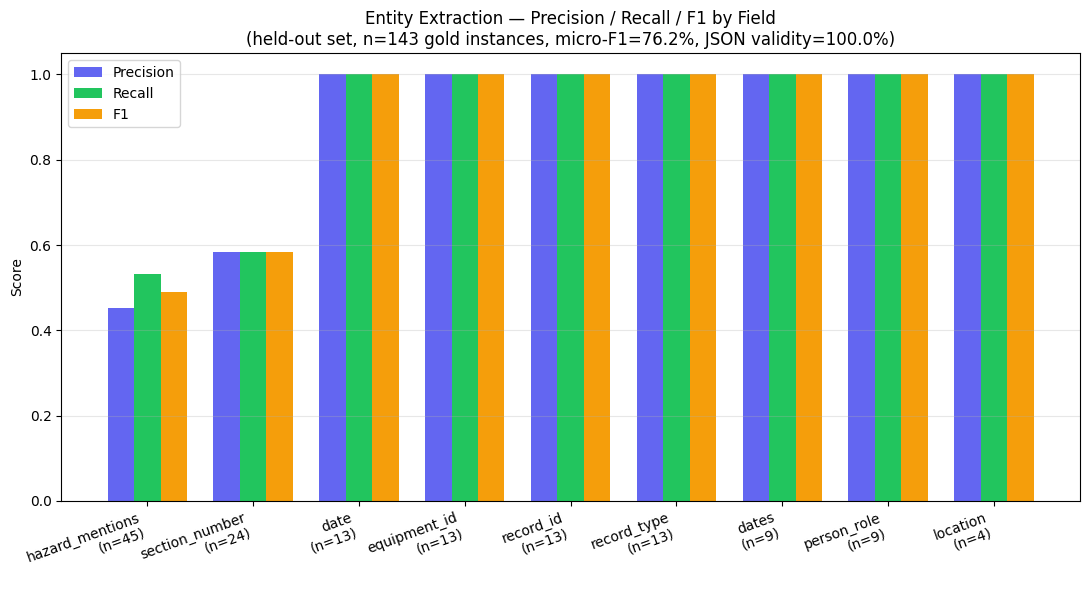

Saved -> /content/drive/MyDrive/ET_Industrial_data/deck_assets/phase_c_prf1_chart.png


In [3]:
"""
Phase C metrics visualization — run anytime, no GPU/model needed.
Reads the metrics.json already saved by phase_c_eval_and_integration.py.
"""

import os
import json
import matplotlib.pyplot as plt
import numpy as np

BASE_PATH = "/content/drive/MyDrive/ET_Industrial_data"
METRICS_PATH = os.path.join(BASE_PATH, "entity_model", "phase_c_metrics.json")
OUT_DIR = os.path.join(BASE_PATH, "deck_assets")
os.makedirs(OUT_DIR, exist_ok=True)

with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics = json.load(f)

fields = [k for k in metrics.keys() if not k.startswith("_")]
fields.sort(key=lambda k: metrics[k]["support"], reverse=True)  # highest-support fields first

precision = [metrics[f]["precision"] for f in fields]
recall = [metrics[f]["recall"] for f in fields]
f1 = [metrics[f]["f1"] for f in fields]
support = [metrics[f]["support"] for f in fields]

x = np.arange(len(fields))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width, precision, width, label="Precision", color="#6366f1")
ax.bar(x, recall, width, label="Recall", color="#22c55e")
ax.bar(x + width, f1, width, label="F1", color="#f59e0b")

ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title(f"Entity Extraction — Precision / Recall / F1 by Field\n"
             f"(held-out set, n={sum(support)} gold instances, "
             f"micro-F1={metrics['_overall_micro']['f1']:.1%}, "
             f"JSON validity={metrics['_json_validity_rate']:.1%})")
ax.set_xticks(x)
ax.set_xticklabels([f"{f}\n(n={s})" for f, s in zip(fields, support)], rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

out_path = os.path.join(OUT_DIR, "phase_c_prf1_chart.png")
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Saved -> {out_path}")

In [4]:
def print_graph_completeness_report(G):
    total_nodes = G.number_of_nodes()
    total_edges = G.number_of_edges()

    # 1. Orphan Nodes (Degree == 0)
    orphans = [node for node in G.nodes() if G.degree(node) == 0]

    # 2. Average Node Degree
    degrees = [deg for _, deg in G.degree()]
    avg_degree = sum(degrees) / total_nodes if total_nodes > 0 else 0

    # 3. % Equipment connected to >= 1 Regulation
    equipments = [n for n, d in G.nodes(data=True) if d.get('type') == 'Equipment']
    covered_equipments = 0

    for eq in equipments:
        # Uses your existing Phase 3 get_regulations_for_equipment helper
        regs = get_regulations_for_equipment(G, eq)
        if len(regs) > 0:
            covered_equipments += 1

    coverage_pct = (covered_equipments / len(equipments) * 100) if equipments else 0.0

    print("\n" + "="*50)
    print("📊 KNOWLEDGE GRAPH COMPLETENESS REPORT")
    print("="*50)
    print(f"• Total Graph Size:             {total_nodes} nodes | {total_edges} edges")
    print(f"• Equipment Regulatory Coverage: {coverage_pct:.1f}% ({covered_equipments}/{len(equipments)} equipments)")
    print(f"• Average Node Density/Degree:   {avg_degree:.2f} links per node")
    print(f"• Orphan Nodes (Unconnected):   {len(orphans)}")
    print("="*50 + "\n")

# Run it directly on your loaded Knowledge Graph
print_graph_completeness_report(KG)


📊 KNOWLEDGE GRAPH COMPLETENESS REPORT
• Total Graph Size:             85 nodes | 114 edges
• Equipment Regulatory Coverage: 100.0% (10/10 equipments)
• Average Node Density/Degree:   2.68 links per node
• Orphan Nodes (Unconnected):   0

